In [32]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import numpy as np
from graphviz import Source
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### Load Dataset

In [2]:
iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

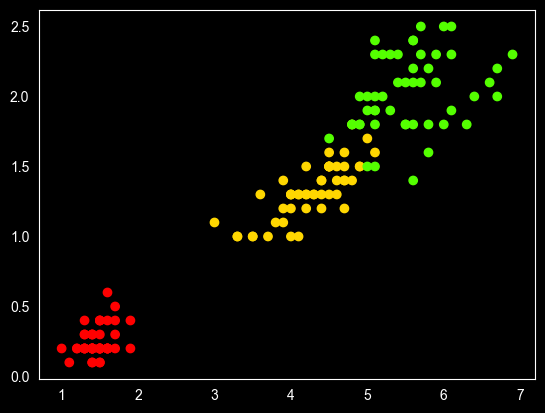

In [8]:
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap="prism")
plt.grid()
plt.show()

### Simple Model


In [12]:
def decision_boundary(tree, X, Y):
    t = tree.tree_
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    plt.figure(figsize=(8, 6))
    def traverse(node, xlim, ylim):
        feature = t.feature[node]
        threshold = t.threshold[node]
        if feature == -2:
            predicted_class = np.argmax(t.value[node][0])
            color = None
            if predicted_class == 0:
                color = "yellow"
            elif predicted_class == 1:
                color = "orange"
            else:
                color = "green"
            plt.fill([xlim[0], xlim[1], xlim[1], xlim[0]], [ylim[0], ylim[0], ylim[1], ylim[1]], color=color, alpha=0.2)
            return
        if feature == 0:
            traverse(t.children_left[node], (xlim[0], threshold), ylim)
            traverse(t.children_right[node], (threshold, xlim[1]), ylim)
        elif feature == 1:
            traverse(t.children_left[node], xlim, (ylim[0], threshold))
            traverse(t.children_right[node], xlim, (threshold, ylim[1]))
    traverse(0, (x_min, x_max), (y_min, y_max))
    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], color="blue", edgecolor="black", label="Class 0")
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], color="orange", edgecolor="black", label="Class 1")
    plt.scatter(X[Y == 2, 0], X[Y == 2, 1], color="green", edgecolor="black", label="Class 2")
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.title("Decision Boundary")
    plt.legend()
    plt.grid()
    plt.show()

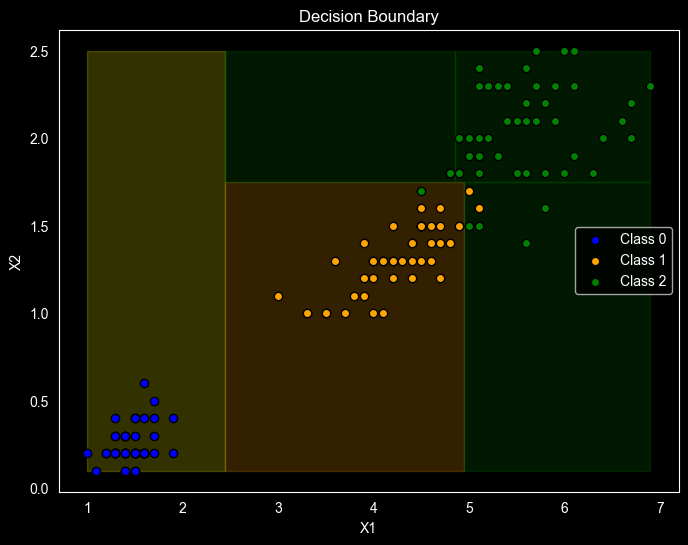

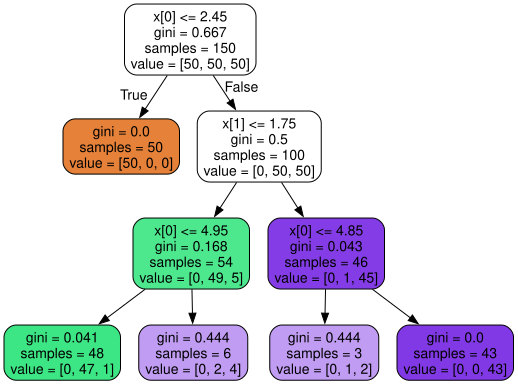

In [30]:
tree_clfx = DecisionTreeClassifier(max_depth=3)
tree_clfx.fit(X_iris, y_iris)
decision_boundary(tree_clfx, X_iris, y_iris)
dot = export_graphviz(tree_clfx, out_file=None, rounded=True, filled=True)
Source(dot)

### PCA

In [33]:
pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
X_iris_rotated

array([[-1.87784285e+00, -1.75236840e-02],
       [-1.87784285e+00, -1.75236840e-02],
       [-1.91803298e+00, -5.77138140e-02],
       [-1.83765272e+00,  2.26664460e-02],
       [-1.87784285e+00, -1.75236840e-02],
       [-1.57111644e+00, -8.31093143e-02],
       [-1.78476484e+00, -1.10601694e-01],
       [-1.83765272e+00,  2.26664460e-02],
       [-1.87784285e+00, -1.75236840e-02],
       [-1.93073073e+00,  1.15744456e-01],
       [-1.83765272e+00,  2.26664460e-02],
       [-1.79746259e+00,  6.28565760e-02],
       [-1.97092086e+00,  7.55543261e-02],
       [-2.09149125e+00, -4.50160639e-02],
       [-1.95822311e+00, -9.79039440e-02],
       [-1.65149670e+00, -1.63489574e-01],
       [-1.73187696e+00, -2.43869834e-01],
       [-1.78476484e+00, -1.10601694e-01],
       [-1.66419445e+00,  9.96869583e-03],
       [-1.74457471e+00, -7.04115642e-02],
       [-1.75727246e+00,  1.03046706e-01],
       [-1.65149670e+00, -1.63489574e-01],
       [-2.03860337e+00, -1.78284204e-01],
       [-1.

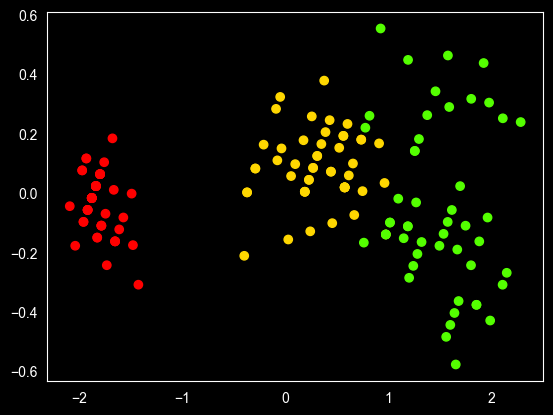

In [35]:
plt.scatter(X_iris_rotated[:, 0], X_iris_rotated[:, 1], c=y_iris, cmap="prism")
plt.grid()
plt.show()

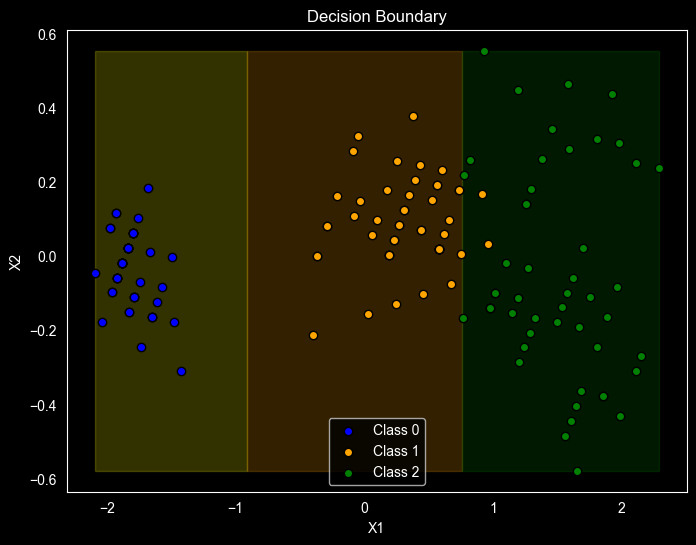

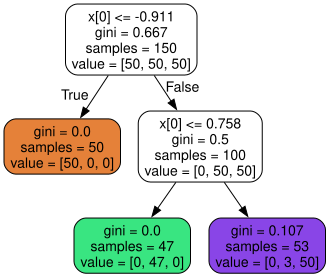

In [46]:
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)
decision_boundary(tree_clf_pca, X_iris_rotated, y_iris)
dot = export_graphviz(tree_clf_pca, out_file=None, rounded=True, filled=True)
Source(dot)